# Dry Bean Classification Using Neural Networks (TensorFlow)

We will now implement the same classification task using TensorFlow.

We will begin by loading and preprocessing the dataset similarly to how we did with PyTorch.

## 1. Importing Libraries

Before starting with data loading and preprocessing, we import all necessary libraries.

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## 2. Loading and Preprocessing the Dataset

Now, we load the dry_bean dataset, separate the features and target, encode the target classes as integers, scale the features to standardize them, and finally convert everything into TensorFlow tensors.


In [11]:
# Load the dataset
df = pd.read_csv('Lecture_10_Dry_Bean_Dataset.csv')

X = df.drop(columns=['Class'])
y = df['Class']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = tf.convert_to_tensor(X_scaled, dtype=tf.float32)
y_tensor = tf.convert_to_tensor(y_encoded, dtype=tf.int32)

print("Features shape:", X_tensor.shape)
print("Target shape:", y_tensor.shape)


Features shape: (13611, 16)
Target shape: (13611,)


<br>

**As we already did the exploratory data analysis part in PyTorch implementation, we will skip that part now.**

## 3. Splitting the Dataset into Training and Test Sets

We split the dataset into training and test subsets using an 80-20 ratio. 

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)


Training features shape: (10888, 16)
Test features shape: (2723, 16)
Training labels shape: (10888,)
Test labels shape: (2723,)


## 4. Creating TensorFlow Datasets for Efficient Batching

TensorFlow’s `tf.data.Dataset` API allows us to batch, shuffle, and feed data to the model during training. We will convert the training and test data into datasets and apply batching and shuffling to the training set.

In [13]:
batch_size = 64

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=10000).batch(batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(batch_size)

print("Train dataset batches:", len(list(train_dataset)))
print("Test dataset batches:", len(list(test_dataset)))


Train dataset batches: 171
Test dataset batches: 43


<br>
The training dataset is divided into 171 batches and the test dataset into 43 batches, based on the chosen batch size of 64. This batching will improve training efficiency by processing smaller groups of samples at a time.

Now, we will build the feed-forward neural network model using Keras.

## 5. Building the Feed-Forward Neural Network (TensorFlow)

We will create a simple feed-forward neural network with two hidden layers, similar to the PyTorch baseline model. The network will use ReLU activations and a softmax output layer for multi-class classification.

In [14]:
model = models.Sequential([
    layers.Input(shape=(16,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(7, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy()]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,399 (13.28 KB)

 Trainable params: 3,399 (13.28 KB)

 Non-trainable params: 0 (0.00 B)

The model consists of two hidden dense layers with 64 and 32 neurons respectively, both using ReLU activation. The output layer has 7 neurons.

There are 3,399 trainable parameters in total, indicating a relatively simple network that should train efficiently without overfitting easily.

Next, we will train this model on the training dataset.


## 6. Training the Neural Network

We will train the model for 30 epochs, using the training dataset we prepared. During training, the model will optimize its parameters to minimize the categorical cross-entropy loss, and we will monitor accuracy as a performance metric.

In [15]:
epochs = 30

history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=test_dataset
)

Epoch 1/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.1600 - sparse_categorical_accuracy: 0.6073 - val_loss: 0.3094 - val_sparse_categorical_accuracy: 0.8979
Epoch 2/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2783 - sparse_categorical_accuracy: 0.9088 - val_loss: 0.2345 - val_sparse_categorical_accuracy: 0.9144
Epoch 3/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2195 - sparse_categorical_accuracy: 0.9234 - val_loss: 0.2167 - val_sparse_categorical_accuracy: 0.9210
Epoch 4/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2198 - sparse_categorical_accuracy: 0.9216 - val_loss: 0.2115 - val_sparse_categorical_accuracy: 0.9221
Epoch 5/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2102 - sparse_categorical_accuracy: 0.9234 - val_loss: 0.2080 - val_sparse_categorical_accuracy: 0.9266
Epoch 6/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2011 - sparse_categorical_accuracy: 0.9250 - val_loss: 0.2093 - val_sparse_categorical_accuracy: 0.9210
Epoc

<br><br>The training results show that the model quickly improved accuracy in the first few epochs and then gradually refined its performance. By the end of training, the model reached about 93.8% training accuracy and 92.5% validation accuracy, indicating strong generalization to unseen data.

The validation loss is relatively stable, suggesting the model is not overfitting despite the high accuracy.

Next, we can plot the training and validation accuracy and loss curves to visualize the learning process over epochs.


## 7. Plotting Training and Validation Metrics

Visualizing the training and validation loss and accuracy over epochs helps us understand the model’s learning behavior, and spot overfitting.


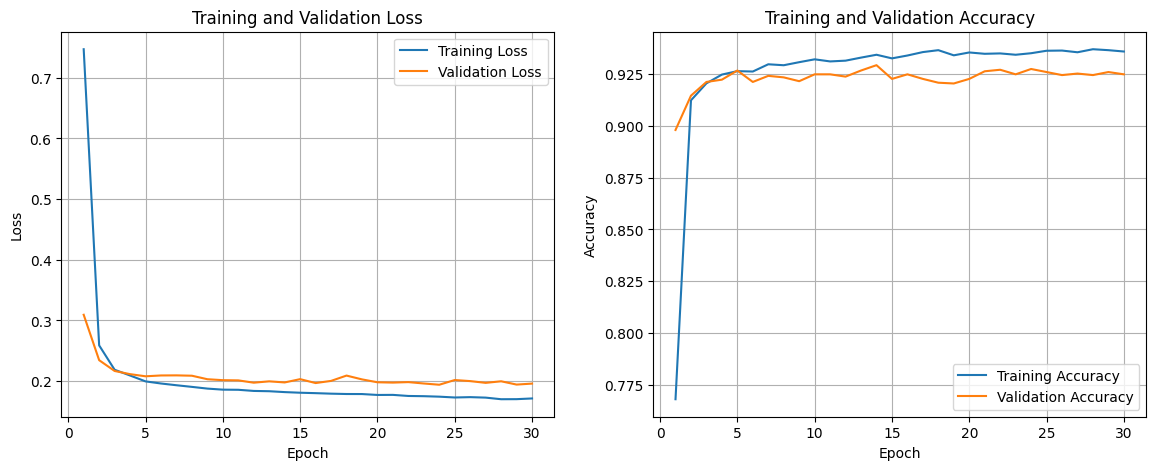

In [16]:
history_dict = history.history

epochs = range(1, len(history_dict['loss']) + 1)

plt.figure(figsize=(14, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['loss'], label='Training Loss')
plt.plot(epochs, history_dict['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['sparse_categorical_accuracy'], label='Training Accuracy')
plt.plot(epochs, history_dict['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()


The plots show that the training loss decreases steadily, and the validation loss closely follows it, indicating stable learning without overfitting.

The training and validation accuracy curves also rise quickly and plateau near 93% and 92.5%, respectively. The close match between training and validation accuracy suggests the model generalizes well to unseen data.

Overall, this confirms that the TensorFlow model performs comparably to the PyTorch model on this task.


## 8. Experimenting with Different Architectures and Optimizers

To improve the model, we can increase the number of layers and neurons or try different optimizers like SGD. This will help us see how sensitive the model is to these changes and find the best configuration for accuracy and training stability.


In [17]:
deeper_model = models.Sequential([
    layers.Input(shape=(16,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(7, activation='softmax')
])

deeper_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy()]
)

deeper_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,743 (49.78 KB)

 Trainable params: 12,743 (49.78 KB)

 Non-trainable params: 0 (0.00 B)

The deeper TensorFlow model has three hidden layers with 128, 64, and 32 neurons respectively, and an output layer of 7 neurons for classification. It contains 12,743 trainable parameters, which is substantially larger than the baseline model. This increased complexity allows the model to potentially learn more intricate patterns.

Next, we can train this deeper model and observe if the extra capacity improves performance.


## 9. Training the Deeper Model

We will train the deeper TensorFlow model for 30 epochs using the same training and validation datasets. This will help us compare its performance to the baseline model.


In [18]:
deeper_history = deeper_model.fit(
    train_dataset,
    epochs=30,
    validation_data=test_dataset
)

Epoch 1/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.0161 - sparse_categorical_accuracy: 0.6615 - val_loss: 0.2390 - val_sparse_categorical_accuracy: 0.9148
Epoch 2/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2195 - sparse_categorical_accuracy: 0.9184 - val_loss: 0.2200 - val_sparse_categorical_accuracy: 0.9188
Epoch 3/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2138 - sparse_categorical_accuracy: 0.9221 - val_loss: 0.2231 - val_sparse_categorical_accuracy: 0.9122
Epoch 4/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1993 - sparse_categorical_accuracy: 0.9277 - val_loss: 0.2122 - val_sparse_categorical_accuracy: 0.9207
Epoch 5/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1941 - sparse_categorical_accuracy: 0.9277 - val_loss: 0.2093 - val_sparse_categorical_accuracy: 0.9225
Epoch 6/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1965 - sparse_categorical_accuracy: 0.9283 - val_loss: 0.2061 - val_sparse_categorical_accuracy: 0.9188
Epoc

The deeper model shows steady improvement in both training and validation accuracy over 30 epochs, reaching around 93.8% training accuracy and 92.5% validation accuracy by the end.

The validation loss and accuracy curves are quite stable, indicating good generalization without signs of overfitting.

Overall, the deeper TensorFlow model performs similarly to the baseline model, matching our findings in PyTorch.


## 10. Plotting Training and Validation Metrics for the Deeper Model

Visualizing the training and validation loss and accuracy will help us understand the learning dynamics and compare with the baseline model.

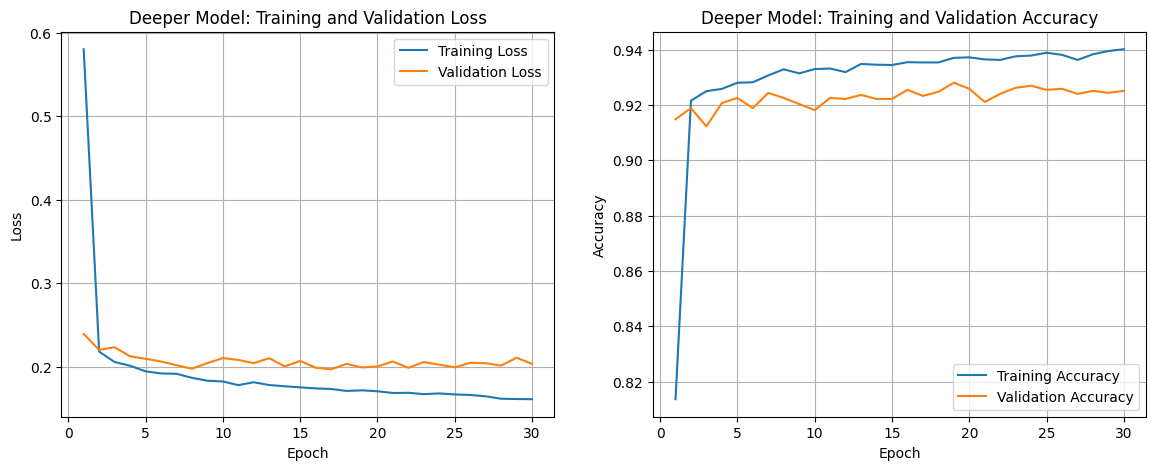

In [19]:
deeper_history_dict = deeper_history.history

epochs = range(1, len(deeper_history_dict['loss']) + 1)

plt.figure(figsize=(14, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(epochs, deeper_history_dict['loss'], label='Training Loss')
plt.plot(epochs, deeper_history_dict['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Deeper Model: Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, deeper_history_dict['sparse_categorical_accuracy'], label='Training Accuracy')
plt.plot(epochs, deeper_history_dict['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Deeper Model: Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()


## Final Comparison: PyTorch vs TensorFlow Models

To conclude, we’ll create a final graph comparing the test accuracies of the baseline and deeper models trained in both PyTorch and TensorFlow. This visualization highlights the performance consistency across frameworks.


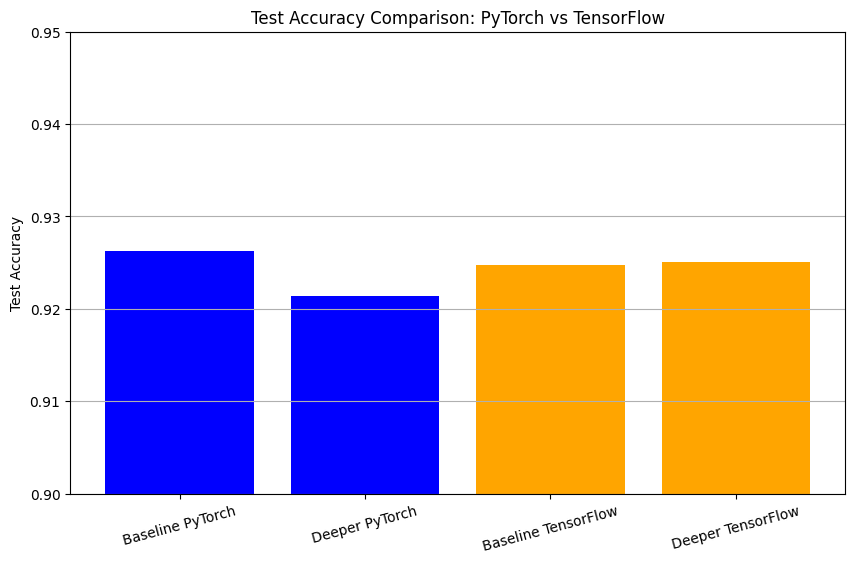

In [22]:
models = ['Baseline PyTorch', 'Deeper PyTorch', 'Baseline TensorFlow', 'Deeper TensorFlow']
test_accuracies = [0.9262, 0.9214, 0.9247, 0.9251]  # Fill in your test accuracies here

x = np.arange(len(models))
plt.figure(figsize=(10, 6))
plt.bar(x, test_accuracies, color=['blue', 'blue', 'orange', 'orange'])
plt.ylim(0.9, 0.95)
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Comparison: PyTorch vs TensorFlow')
plt.xticks(x, models, rotation=15)
plt.grid(axis='y')
plt.show()


The final comparison chart shows that the test accuracies of both baseline and deeper models are very close between PyTorch and TensorFlow. This confirms that both frameworks can effectively solve the Dry Bean classification problem with comparable performance.